# Exploratory Data Analysis (EDA) for BMW Global Automotive Sales

In [276]:
%pip install pandas numpy missingno seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [277]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from scipy.stats import kruskal

In [278]:
train_file_path = "bmw_global_sales_2018_2025.csv" 
df = pd.read_csv(train_file_path)
print("Full train dataset shape is {}".format(df.shape))

Full train dataset shape is (3072, 11)


In [279]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [280]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [281]:
# Inspect column names and view any potential whitespaces
print("Column names with potential leading/trailing whitespaces:" + f"{df.columns.tolist()}")

Column names with potential leading/trailing whitespaces:['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR', 'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth', 'Fuel_Price_Index']


<AxesSubplot:>

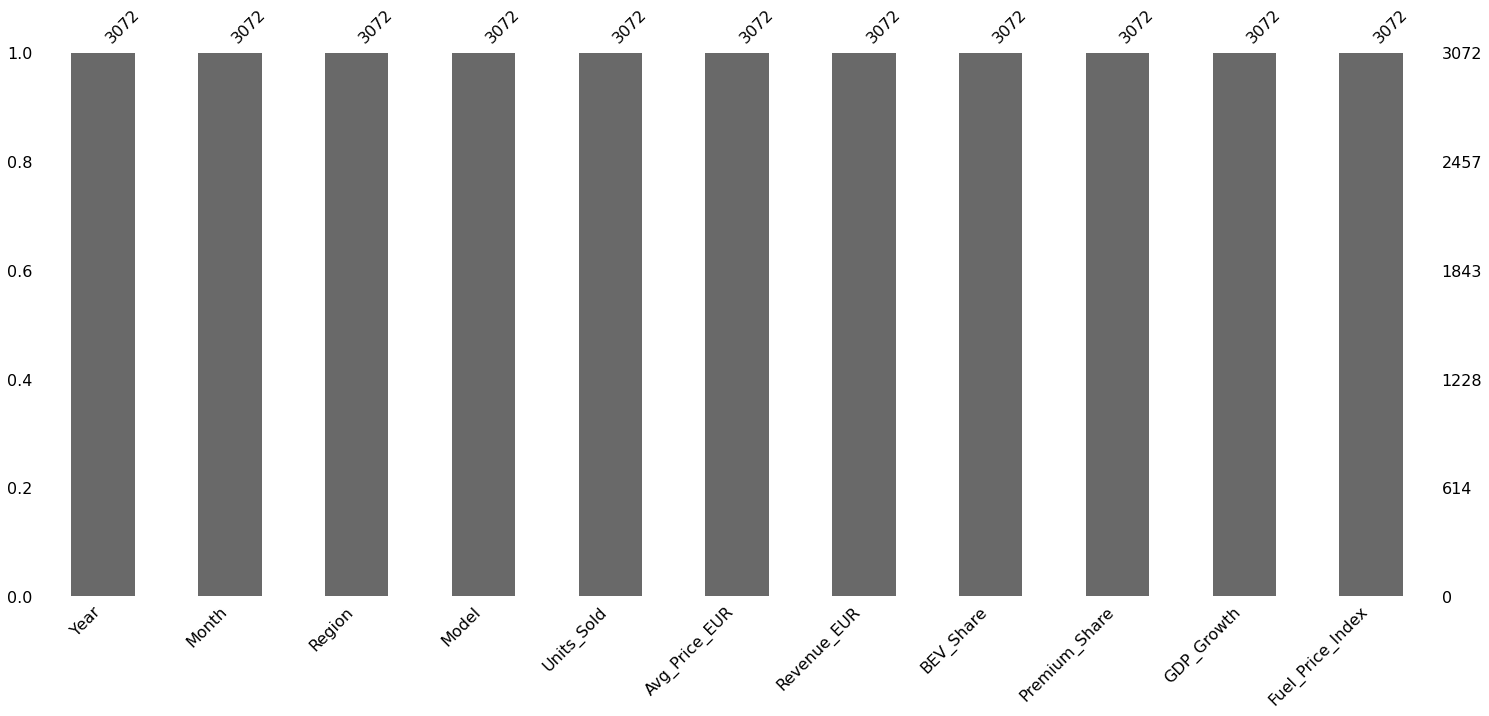

In [282]:
msno.bar(df)

<AxesSubplot:>

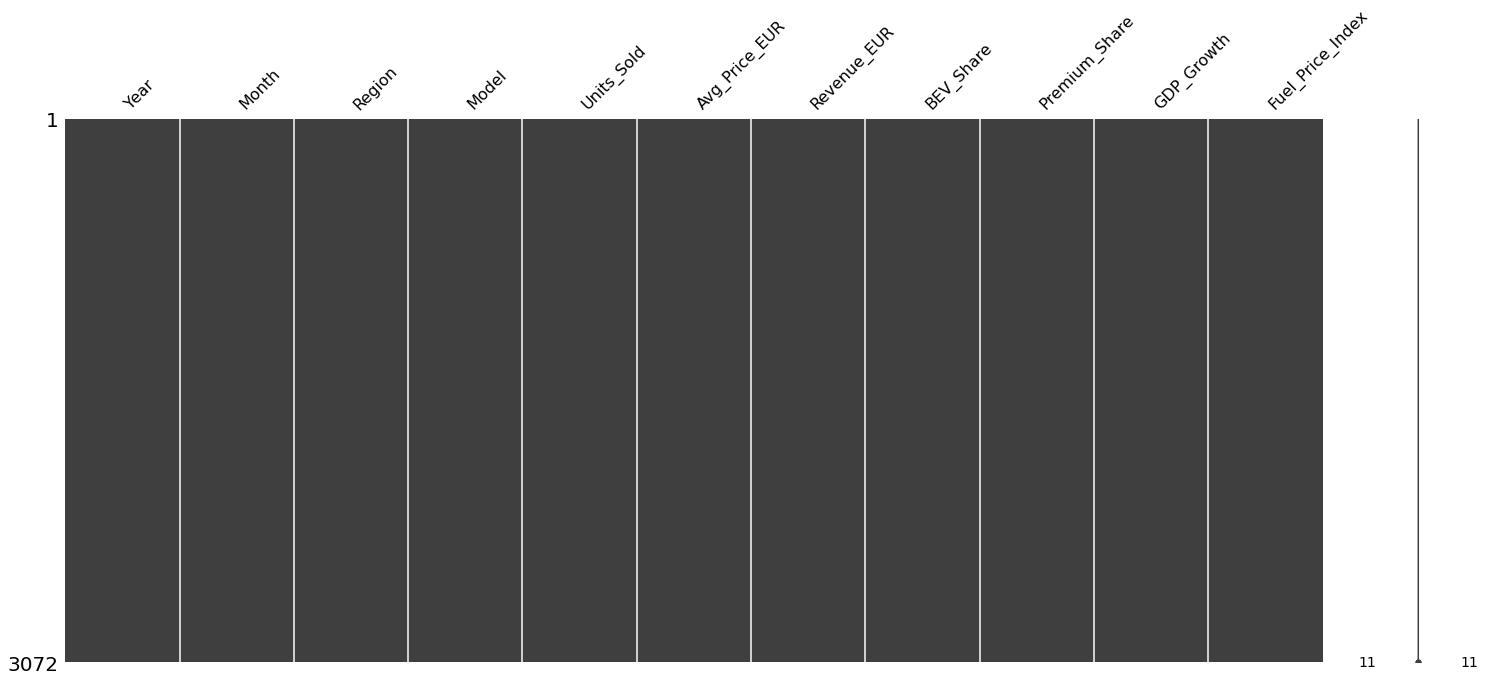

In [283]:
msno.matrix(df)

Univariate Analysis:

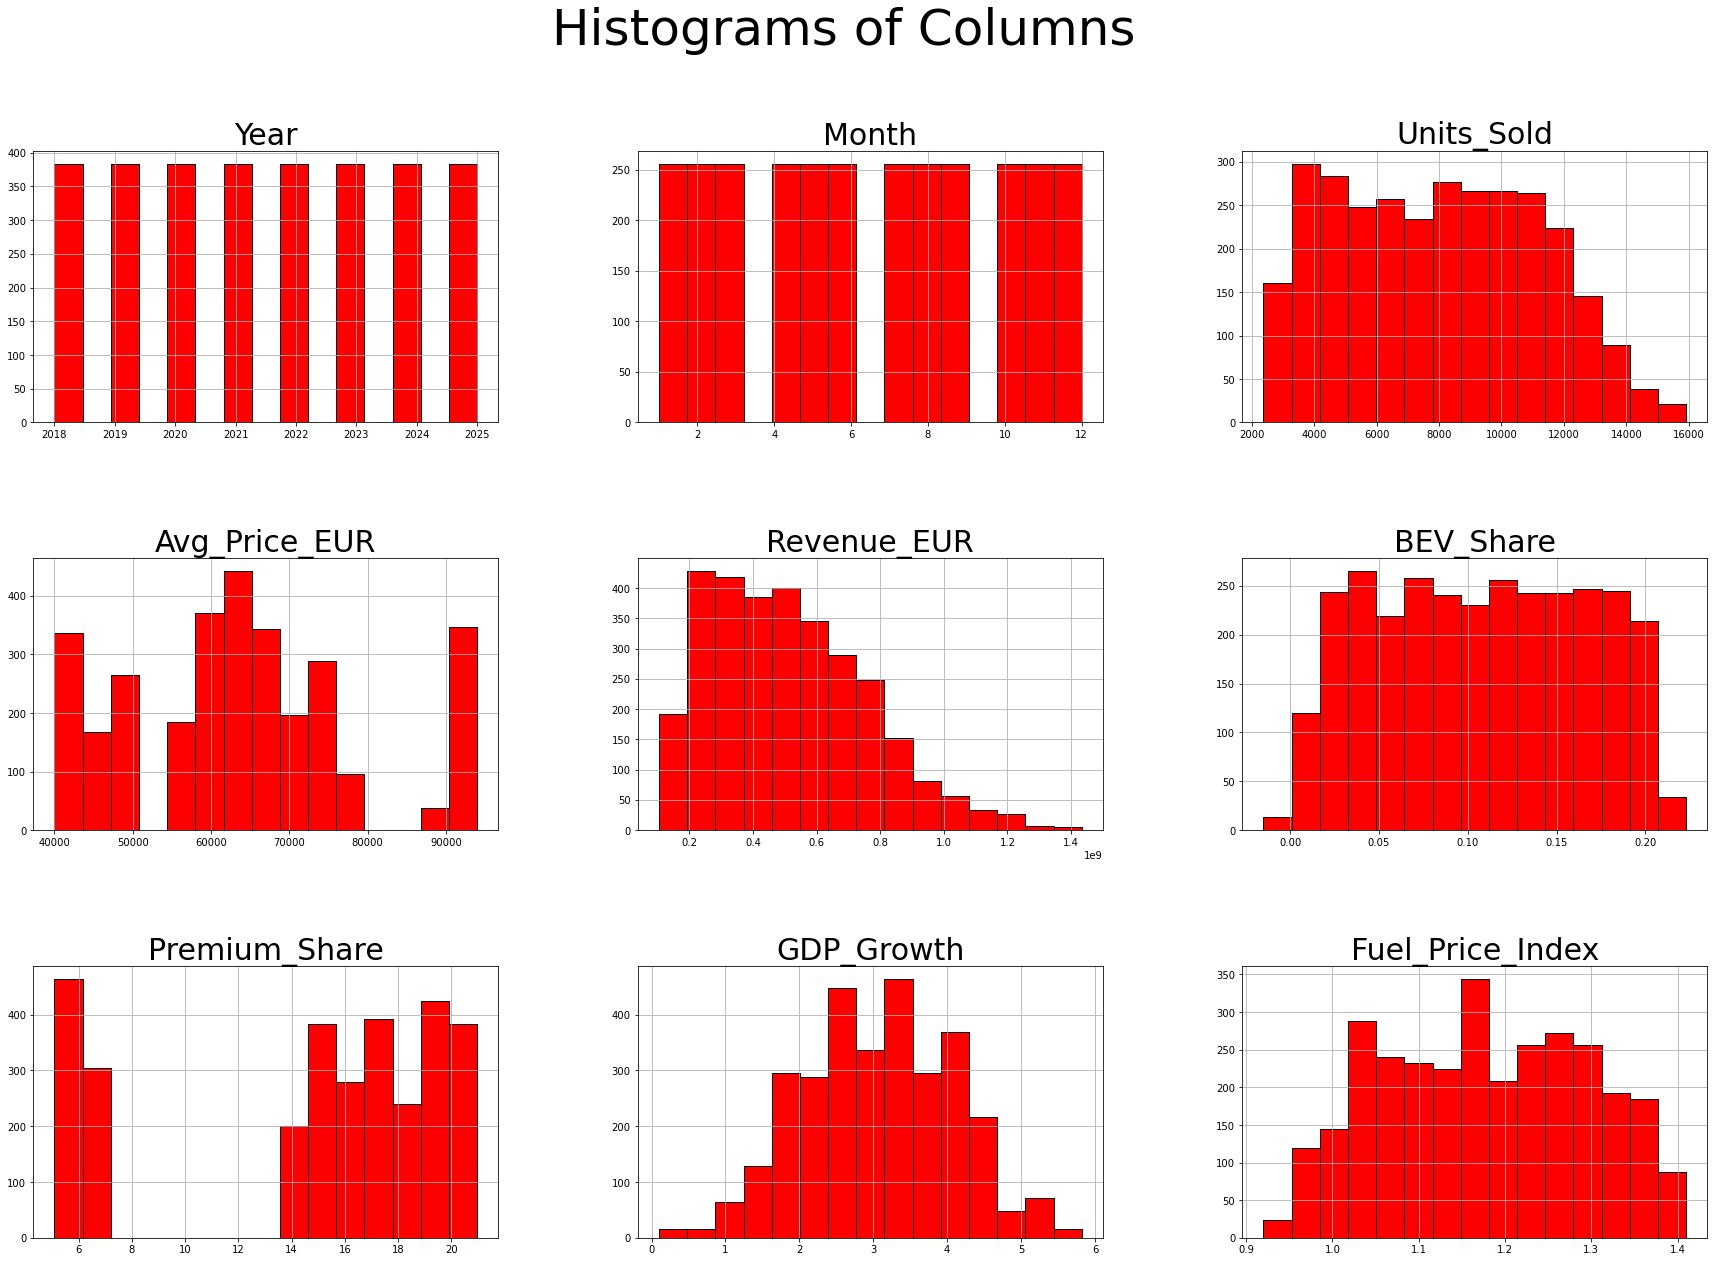

In [284]:
# Overall Histogram
df.hist(bins=15, figsize=(30, 20), color='red', edgecolor='black')
plt.suptitle('Histograms of Columns', fontsize=50)
plt.rcParams['axes.titlesize'] = 30
plt.subplots_adjust(hspace=0.5)
plt.show()

In [285]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,3072.0,2.021500e+03,2.291661e+00,2.018000e+03,2.019750e+03,2.021500e+03,2.023250e+03,2.025000e+03
Month,3072.0,6.500000e+00,3.452615e+00,1.000000e+00,3.750000e+00,6.500000e+00,9.250000e+00,1.200000e+01
Units_Sold,3072.0,7.980288e+03,3.174917e+03,2.379000e+03,5.225500e+03,7.985500e+03,1.052825e+04,1.591400e+04
Avg_Price_EUR,3072.0,6.385456e+04,1.465589e+04,4.001100e+04,5.450025e+04,6.349300e+04,7.148950e+04,9.399400e+04
Revenue_EUR,3072.0,5.113995e+08,2.431185e+08,1.045314e+08,3.125504e+08,4.808690e+08,6.709141e+08,1.433482e+09
BEV_Share,3072.0,1.075723e-01,5.809870e-02,-1.500000e-02,5.700000e-02,1.080000e-01,1.572500e-01,2.230000e-01
Premium_Share,3072.0,1.466023e+01,5.334604e+00,5.090000e+00,1.227500e+01,1.626000e+01,1.893250e+01,2.097000e+01
GDP_Growth,3072.0,3.057526e+00,1.018103e+00,1.000000e-01,2.370000e+00,3.060000e+00,3.852500e+00,5.820000e+00
Fuel_Price_Index,3072.0,1.176224e+00,1.181230e-01,9.200000e-01,1.080000e+00,1.180000e+00,1.270000e+00,1.410000e+00


In [286]:
df.mode(numeric_only=True)

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018.0,1.0,5827.0,42933.0,104531427,0.119,6.87,2.37,1.18
1,2019.0,2.0,10119.0,47777.0,109550032,NaN,NaN,2.40,NaN
2,2020.0,3.0,NaN,70920.0,109834770,NaN,NaN,4.00,NaN
3,2021.0,4.0,NaN,93843.0,112827428,NaN,NaN,NaN,NaN
4,2022.0,5.0,NaN,NaN,113515652,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3067,NaN,NaN,NaN,NaN,1357854577,NaN,NaN,NaN,NaN
3068,NaN,NaN,NaN,NaN,1362720307,NaN,NaN,NaN,NaN
3069,NaN,NaN,NaN,NaN,1364422508,NaN,NaN,NaN,NaN
3070,NaN,NaN,NaN,NaN,1374545720,NaN,NaN,NaN,NaN


Bivariate Analysis:

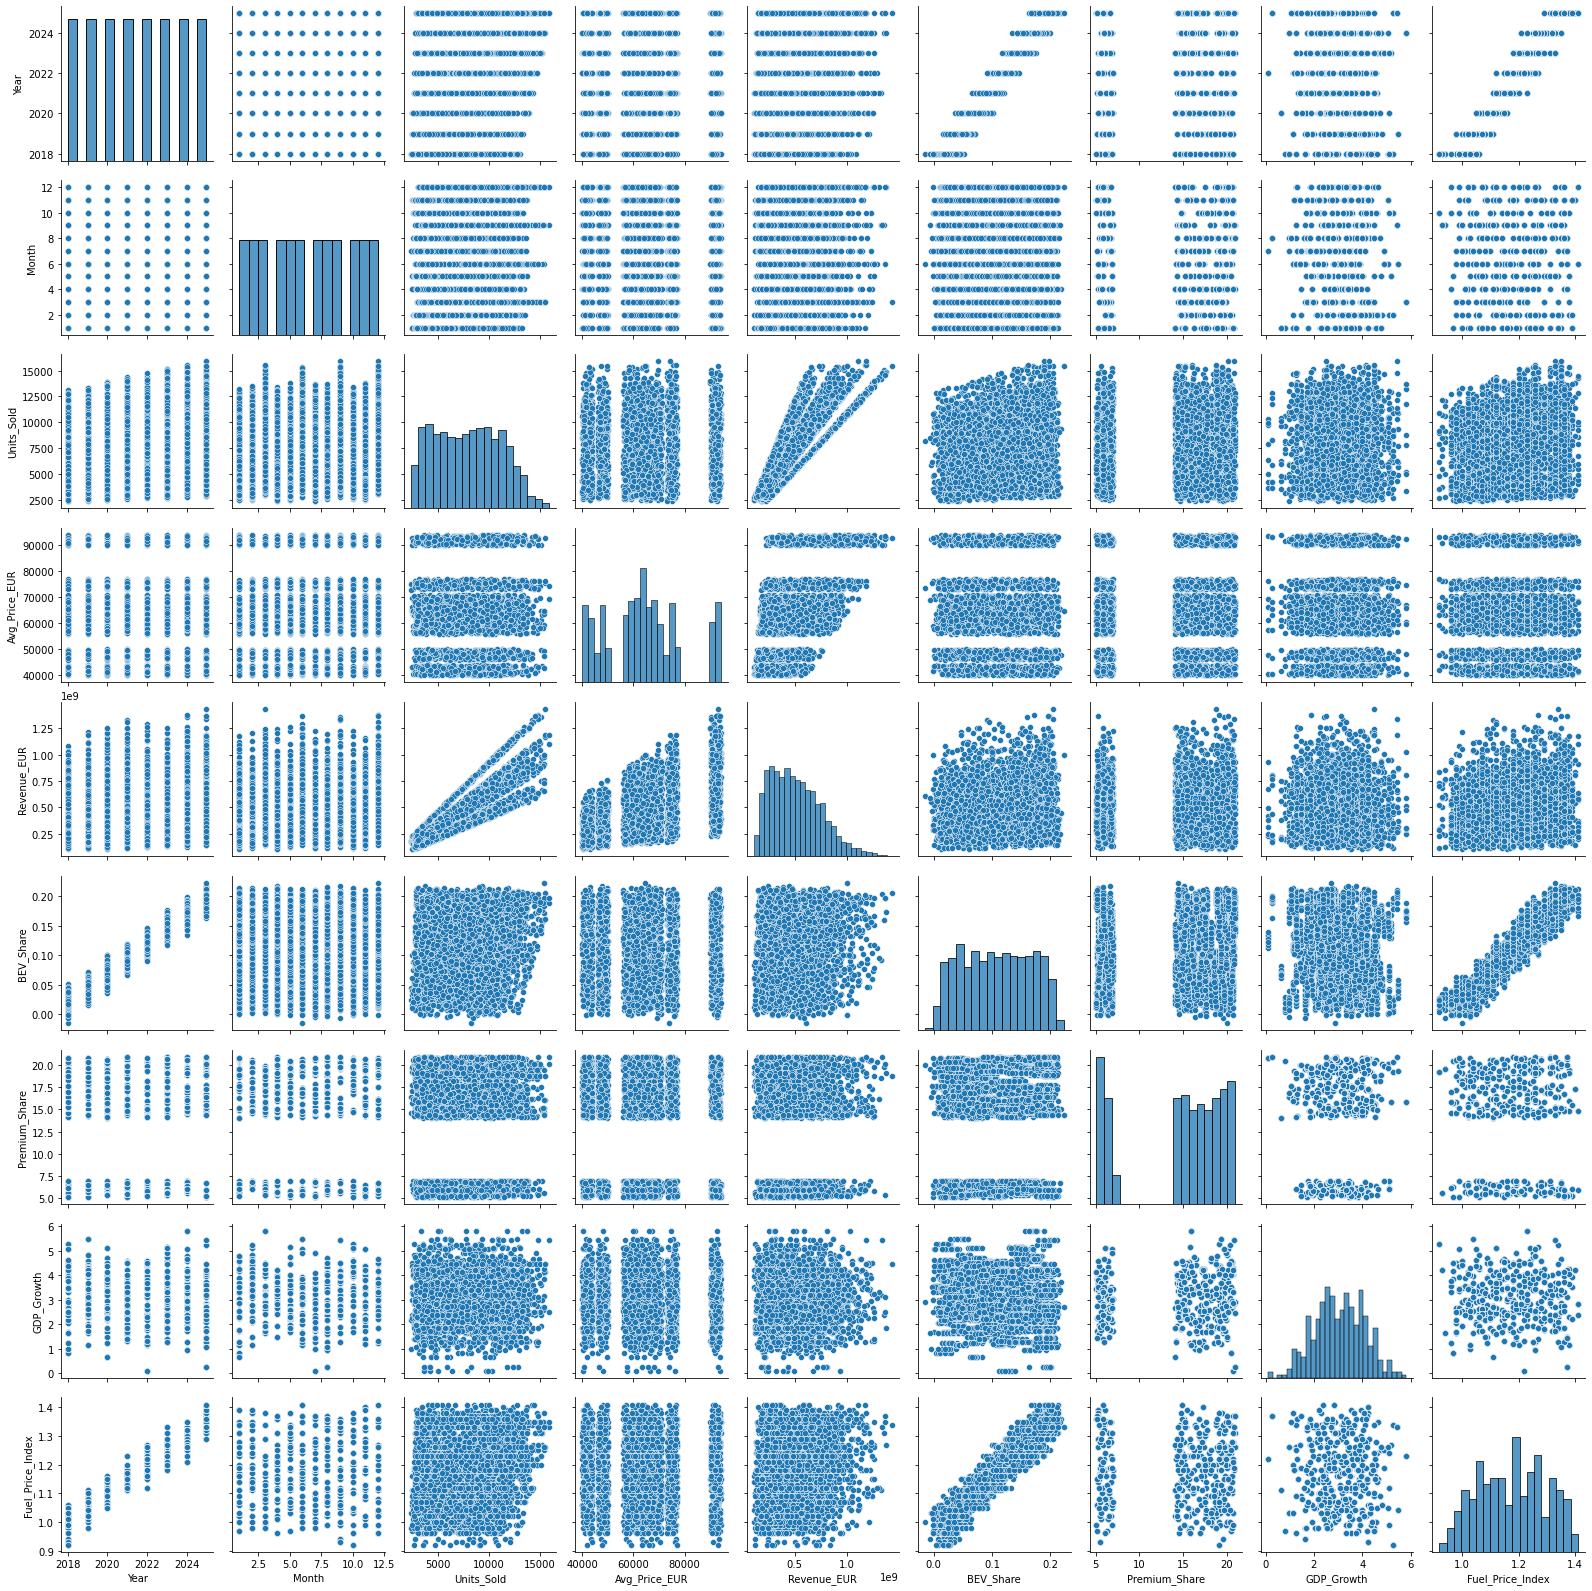

In [287]:
# Pairplot for numeric columns
numeric_cols = df.select_dtypes(include='number').columns
sns.pairplot(df[numeric_cols])
plt.show()


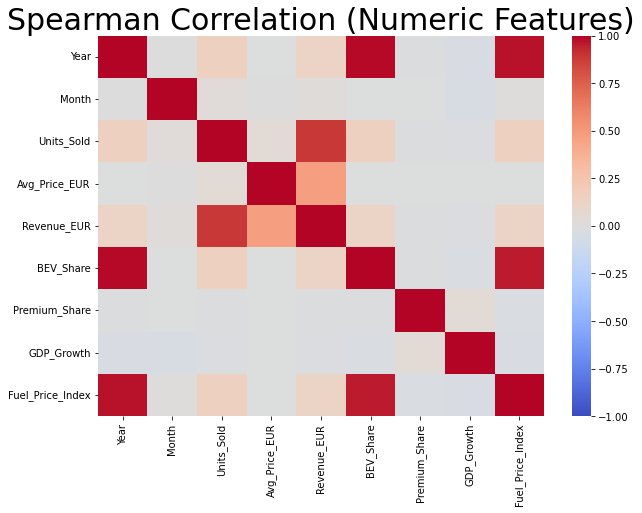

In [288]:
corr = df.select_dtypes(include='number').corr(method='spearman')
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Spearman Correlation (Numeric Features)')
plt.show()

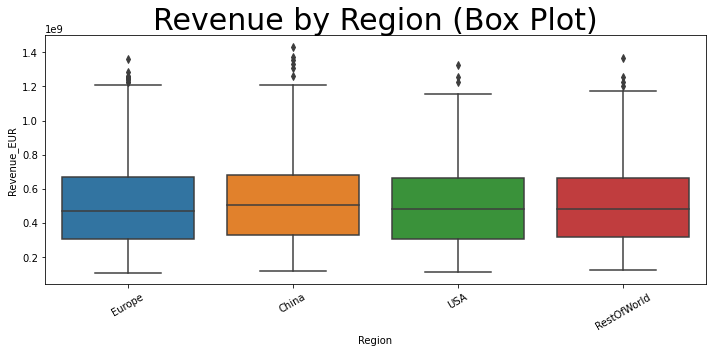

In [289]:
#Revenue by Region (Box Plot)
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Region', y='Revenue_EUR')
plt.xticks(rotation=30)
plt.title('Revenue by Region (Box Plot)')
plt.tight_layout()
plt.show()

Revenue_EUR by Region interpretation:

1. Central tendency (medians): All four regions have similar median revenues (roughly in the €0.45–0.50B range per period in your dataset).
China appears slightly higher in median than the others, but the difference is modest and there’s heavy overlap.

2. Spread (IQR: box height): China shows a wider IQR than the others → more variability from one period/observation to another.
Europe, USA, RestOfWorld have similar IQRs, a bit tighter than China.

3. Skew & whiskers: All regions show a longer upper whisker and many high-end outliers → right‑skewed distributions (a few very large revenue periods).
Lower whiskers are shorter and closer to the box → fewer extremely low periods

4. Outliers (extreme highs). All regions have high outliers above ~€1.2B. China shows the highest extremes (some points near €1.4–1.45B), followed by Europe/USA/RestOfWorld with outliers up to ~€1.3–1.35B.

5.  Group overlap: Boxes and whiskers heavily overlap across regions. Visual differences exist (China: higher variability and slightly higher median), but the distributions are broadly similar.

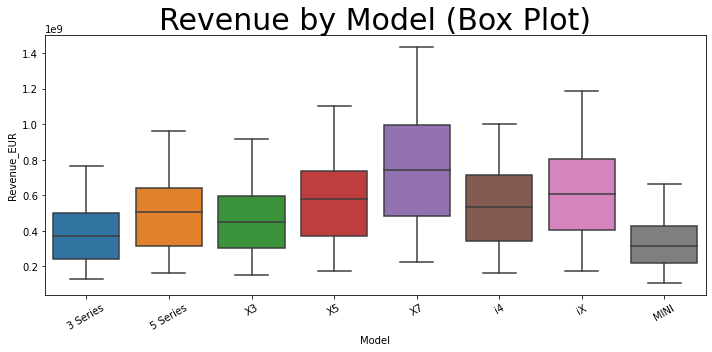

In [290]:
#Revenue by BMW Model (Box Plot)
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Model', y='Revenue_EUR')
plt.xticks(rotation=30)
plt.title('Revenue by Model (Box Plot)')
plt.tight_layout()
plt.show()


Revenue_EUR by Model interpretation:

X7:
Highest median revenue among models.
Widest IQR → the most variability of the middle 50%.
Several extreme outliers, reaching roughly €1.4B.
Takeaway: top typical revenue but with large volatility (big upside periods).

iX:
High median, second tier behind X7.
Wide spread with multiple high outliers (≈ up to €1.18B).
Takeaway: strong revenue with occasional large spikes.

i4 and X5:
Upper‑mid medians.
Moderate-to‑wide IQRs; outliers up to ~€1.0–1.1B.
Takeaway: solid typical performance with periodic peak periods.

X3 and 5 Series:
Mid‑range medians.
Moderate variability; some high outliers (≈ up to €0.9–1.0B).
Takeaway: consistent mid‑tier revenue.

3 Series:
Lower median relative to the above.
Narrower IQR than the SUVs and i‑models.
Takeaway: more stable but lower typical revenue.


MINI:
Lowest median and one of the tightest spreads.
Few high outliers (≈ up to €0.65–0.7B).
Takeaway: smaller typical revenue and relatively consistent.




Overlap: Boxes/whiskers overlap across several models, so while X7 (and to a degree iX) stands out, differences are suggestive rather than conclusive without statistical testing.

In [291]:
# ANOVA (Parametric) , Revenue by Region
groups = [g['Revenue_EUR'] for _, g in df.groupby('Region')]
f_oneway(*groups)


F_onewayResult(statistic=0.8127239191462325, pvalue=0.48667367013935636)

In [292]:
#  Kruskal–Wallis (Non‑parametric), Revenue by Region
kruskal(*groups)

KruskalResult(statistic=3.07829116670473, pvalue=0.3797110284833964)

Categorical vs Categorical:

<AxesSubplot:xlabel='Region', ylabel='count'>

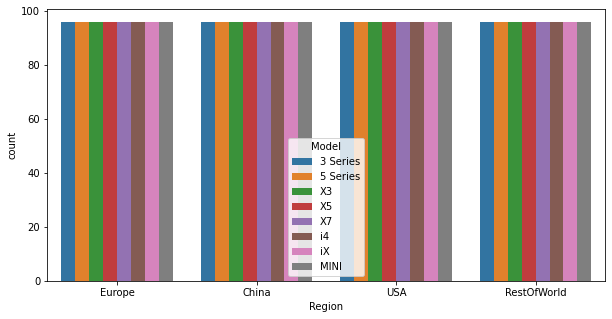

In [293]:
plt.figure(figsize=(10,5))
sns.countplot(x='Region', hue='Model', data=df)

Multivariate Analysis:

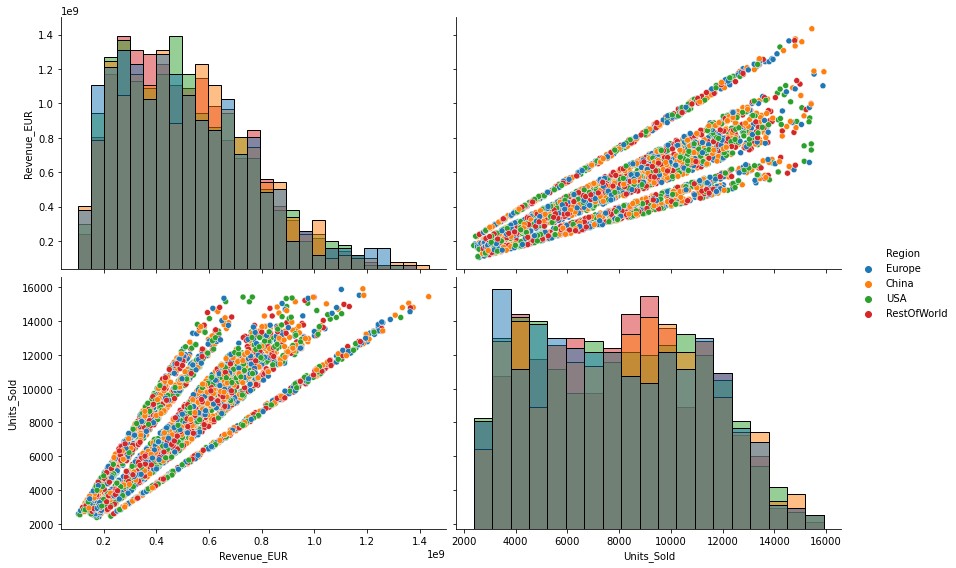

In [302]:
sns.pairplot(df, vars=['Revenue_EUR', 'Units_Sold'], hue='Region',diag_kind="hist", height=4, aspect=1.5)

Interpretation:

**Revenue vs Units (off‑diagonal scatter):**

There’s a very strong positive relationship: as Units_Sold increases, Revenue_EUR increases almost linearly.
Points form several clear, parallel diagonal bands rather than one continuous cloud.

This is typical when Revenue ≈ Units × Avg_Price, and Avg_Price takes on a few common levels (e.g., model/trim/segment price tiers or discount buckets).


Colors are mixed within each band → those price tiers are not region‑specific; regions share similar price levels.
The point spread widens at higher units (mild heteroscedasticity): variance in revenue grows with volume.

Takeaway: Revenue is volume‑led, modulated by a handful of price/mix tiers (likely model/trim effects), and this relationship is consistent across regions.

**Distributions (diagonal KDEs):**

Revenue_EUR (top‑left KDE): All regions have similar right‑skewed distributions with peaks around ~€0.3–0.6B and long upper tails. China/RestOfWorld show slightly heavier right tails, suggesting more high‑revenue periods.
Units_Sold (bottom‑right KDE): Regions overlap, but China’s density appears shifted to somewhat higher units, with Europe/USA a bit lower and RestOfWorld slightly broader.

Takeaway: Typical revenue levels are comparable across regions; China tends to hit higher unit volumes more often, which contributes to its higher revenue tail.

<AxesSubplot:>

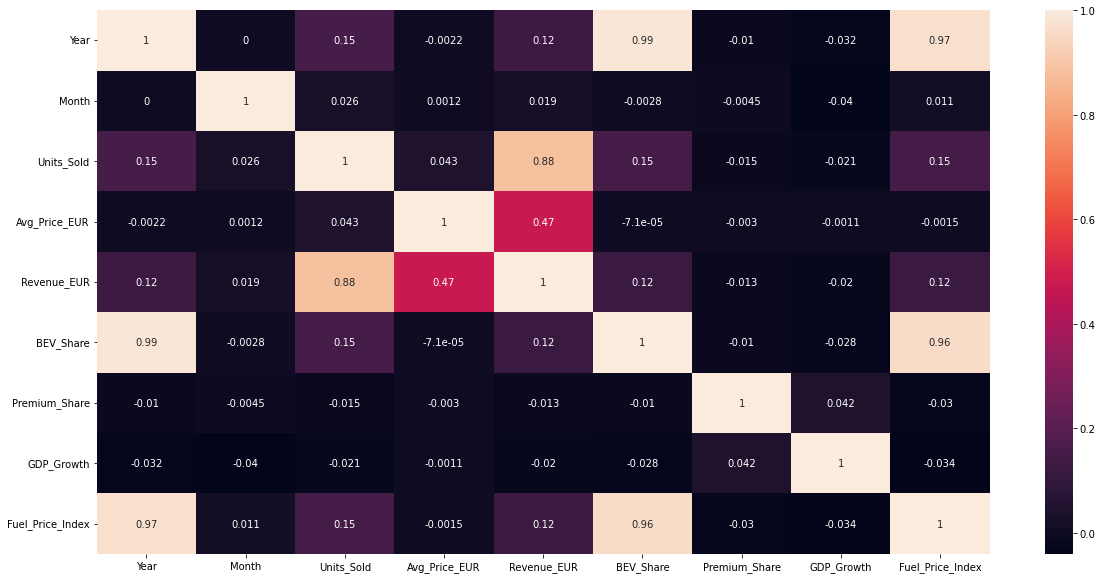

In [295]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(df.corr(method='spearman'), annot=True)

Detecting Outliers:

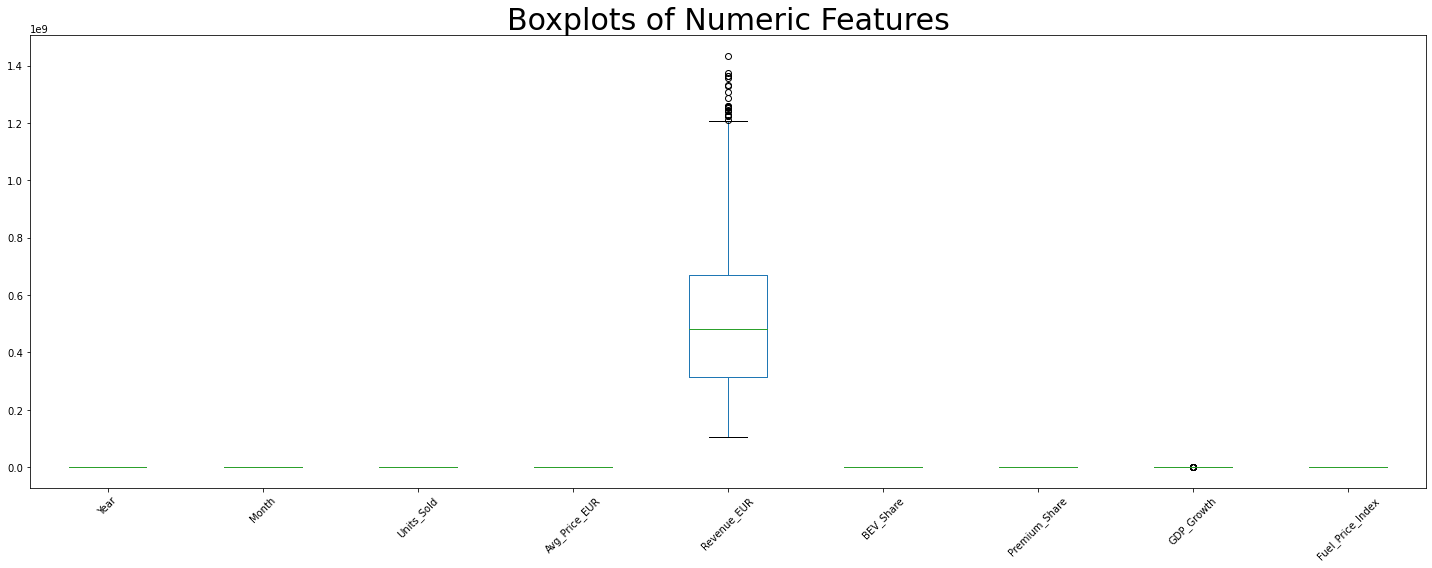

In [296]:
# Overall numeric data Boxplot for detecting outliers
df.select_dtypes(include='number').boxplot(figsize=(20, 8), rot=45, grid=False)
plt.title("Boxplots of Numeric Features")
plt.tight_layout()
plt.show()




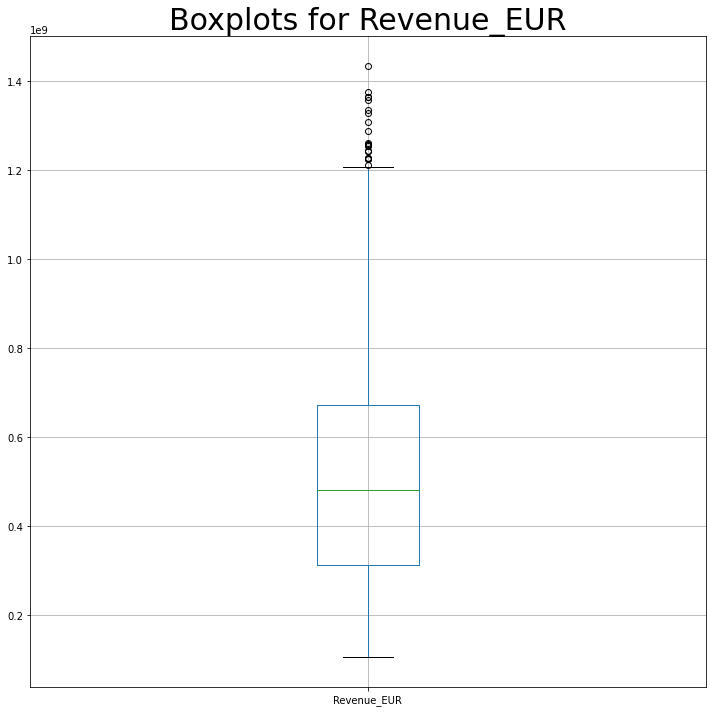

In [ ]:
UUpdateuuuuutttasdaaa

In [298]:
# View outlier for Revenue_EUR
outlier_Revenue = df[df['Revenue_EUR']>df['Revenue_EUR'].quantile(0.95)]
print('\n\n', outlier_Revenue['Revenue_EUR'])



 68      1084058655
76      1008269216
108     1034331726
140     1023939630
356      997721730
           ...    
3046    1066935510
3053     995623140
3060    1090113312
3062    1013498080
3068    1174161615
Name: Revenue_EUR, Length: 154, dtype: int64


In [299]:
for i in df.columns: # checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Year  :  0
Month  :  0
Region  :  0
Model  :  0
Units_Sold  :  0
Avg_Price_EUR  :  0
Revenue_EUR  :  0
BEV_Share  :  0
Premium_Share  :  0
GDP_Growth  :  0
Fuel_Price_Index  :  0


In [300]:
df.duplicated().sum() # total count of duplicate rows present in the DataFrame:

0